## Rossmann Store Sales Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet

## Loading & Exploring data

In [2]:
train = pd.read_csv('../data/train.csv')
store = pd.read_csv('../data/store.csv')
df = pd.merge(train, store, on='Store', how='left')
df.shape

C:\Users\PC\AppData\Local\Temp\ipykernel_4400\231671917.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../data/train.csv')


(1017209, 18)

In [3]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

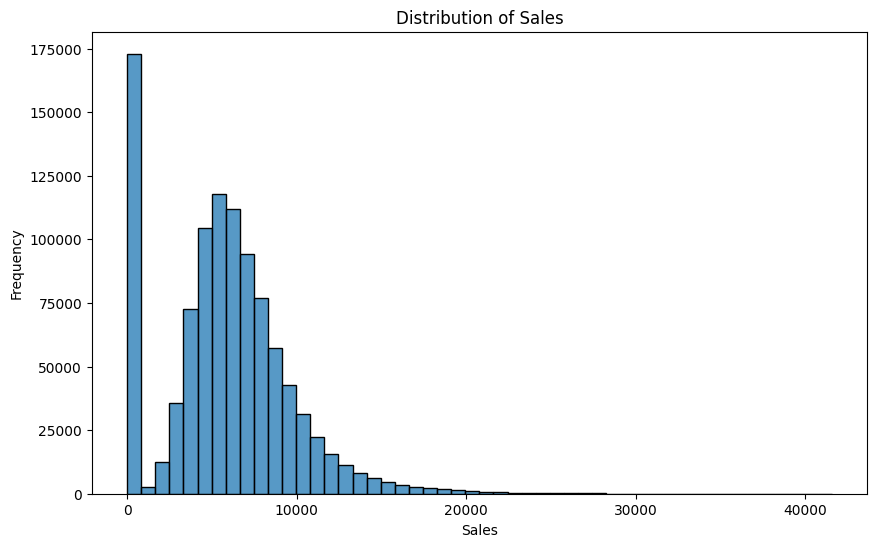

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

## Cleaning

In [6]:
df = df[df['Open'] == 1]
df['Date'] = pd.to_datetime(df['Date'])

### Handling Missing Values

In [7]:
df['StateHoliday'] = df['StateHoliday'].astype(str)
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(0)
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0).astype(int)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0).astype(int)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0).astype(int)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0).astype(int)
df['PromoInterval'] = df['PromoInterval'].fillna('0')

## Feature Engineering

### Extracting Date Features

In [8]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

### Promo Interval Casting

In [9]:
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'}

df['IsPromo2Month'] = [
    1 if str(pi) != '0' and month_map[m] in str(pi) else 0 
    for m, pi in zip(df['Month'], df['PromoInterval'])
]

### Categorical Encoding

In [10]:
df['Assortment'] = OrdinalEncoder(categories=[['a', 'b', 'c']]).fit_transform(df[['Assortment']])
df = pd.get_dummies(df, columns=['StateHoliday', 'StoreType', 'DayOfWeek'], drop_first=True)

### Lag & Rolling (Time Series Features)

In [11]:
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

df["sales_lag_7"] = df.groupby("Store")["Sales"].shift(7)
df["sales_lag_14"] = df.groupby("Store")["Sales"].shift(14)

df["rolling_mean_7"] = df.groupby("Store")["Sales"].transform(lambda x: x.shift(1).rolling(7).mean())
df["rolling_mean_30"] = df.groupby("Store")["Sales"].transform(lambda x: x.shift(1).rolling(30).mean())

In [12]:
df.isna().sum()

Store                            0
Date                             0
Sales                            0
Customers                        0
Open                             0
Promo                            0
SchoolHoliday                    0
Assortment                       0
CompetitionDistance              0
CompetitionOpenSinceMonth        0
CompetitionOpenSinceYear         0
Promo2                           0
Promo2SinceWeek                  0
Promo2SinceYear                  0
PromoInterval                    0
Year                             0
Month                            0
Day                              0
WeekOfYear                       0
IsPromo2Month                    0
StateHoliday_a                   0
StateHoliday_b                   0
StateHoliday_c                   0
StoreType_b                      0
StoreType_c                      0
StoreType_d                      0
DayOfWeek_2                      0
DayOfWeek_3                      0
DayOfWeek_4         

In [13]:
df.dropna(inplace=True)

## Model Training & Evaluation

In [14]:
df = df.sort_values("Date").reset_index(drop=True)

X = df.drop(['Sales', 'Date', 'Customers', 'PromoInterval', 'Open'], axis=1)
y = df['Sales']

# Time-based split to prevent data leakage (no shuffling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

### RMSPE 

We evaluate models using RMSPE (Root Mean Square Percentage Error) which was the official metric used in the Kaggle competition.

In [15]:
def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask])**2))

In [16]:
y_train_log = np.log1p(y_train)

ridge = ElasticNet(random_state=42)
ridge.fit(X_train, y_train_log)
y_pred = np.expm1(ridge.predict(X_test))

print(f"RMSPE: {rmspe(y_test, y_pred):.4f}")

RMSPE: 0.3227
